Imports library & Dataset

In [12]:
import pandas as pd
import numpy as np


url = "https://raw.githubusercontent.com/just-abir/AI_ML_Lab_Task/refs/heads/main/Lab_Task_AI_ML/Desicion_Tree/Dataset/Diabetes.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Step 2: Data Processing**

In [13]:
# ---- Data Preprocessing ----

# Columns where 0 is not a valid physiological value -> treat as missing
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_as_missing:
    df[col] = df[col].replace(0, np.nan)

print("Missing values per column:\n", df.isnull().sum())

# Impute missing values with median (robust to outliers)
for col in zero_as_missing:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after imputation:\n", df.isnull().sum())

# ---- Encode categorical features ----
# This dataset is fully numeric, but we demonstrate encoding for completeness
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns found:", categorical_cols)

if len(categorical_cols) > 0:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])
else:
    print("No categorical columns to encode — dataset is fully numeric.")

df.head()

Missing values per column:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Categorical columns found: []
No categorical columns to encode — dataset is fully numeric.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


**Step4:  Train Split + Cart with Cross Validation Tunning**

In [14]:
# ---- Train/Test Split ----
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ---- CART (Gini) Implementation with Hyperparameter Tuning ----
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20]
}

cart_base = DecisionTreeClassifier(criterion='gini', random_state=42)

cart_grid = GridSearchCV(cart_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
cart_grid.fit(X_train, y_train)

cart_best = cart_grid.best_estimator_
print("Best CART params:", cart_grid.best_params_)
print("Best CV accuracy:", cart_grid.best_score_)

Train shape: (614, 8) Test shape: (154, 8)
Best CART params: {'max_depth': 3, 'min_samples_split': 20}
Best CV accuracy: 0.750912968146075


**STEP 5 :  ID3 (Entropy) Implementation with Cross-Validation Tuning**

In [15]:
# ---- ID3 (Entropy) Implementation with Hyperparameter Tuning ----
id3_base = DecisionTreeClassifier(criterion='entropy', random_state=42)

id3_grid = GridSearchCV(id3_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
id3_grid.fit(X_train, y_train)

id3_best = id3_grid.best_estimator_
print("Best ID3 params:", id3_grid.best_params_)
print("Best CV accuracy:", id3_grid.best_score_)

Best ID3 params: {'max_depth': 3, 'min_samples_split': 20}
Best CV accuracy: 0.7557910169265626


**Step 6: Predictions + Evaluation Metrics (Accuracy, Precision, Recall, F1, AUC)**

In [16]:
# ---- Predictions & Evaluation Metrics ----
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
cart_pred = cart_best.predict(X_test)
id3_pred = id3_best.predict(X_test)

# Probabilities for AUC/ROC
cart_proba = cart_best.predict_proba(X_test)[:, 1]
id3_proba = id3_best.predict_proba(X_test)[:, 1]

# Metrics function
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_proba)
    }

cart_metrics = get_metrics(y_test, cart_pred, cart_proba)
id3_metrics = get_metrics(y_test, id3_pred, id3_proba)

print("CART (Gini) Metrics:", cart_metrics)
print("ID3 (Entropy) Metrics:", id3_metrics)

CART (Gini) Metrics: {'Accuracy': 0.6883116883116883, 'Precision': 0.6363636363636364, 'Recall': 0.25925925925925924, 'F1': 0.3684210526315789, 'AUC': np.float64(0.7640740740740741)}
ID3 (Entropy) Metrics: {'Accuracy': 0.6883116883116883, 'Precision': 0.6363636363636364, 'Recall': 0.25925925925925924, 'F1': 0.3684210526315789, 'AUC': np.float64(0.7526851851851852)}


**Step 7: Confusion Matrix Heatmap (2x1 Comparison)**

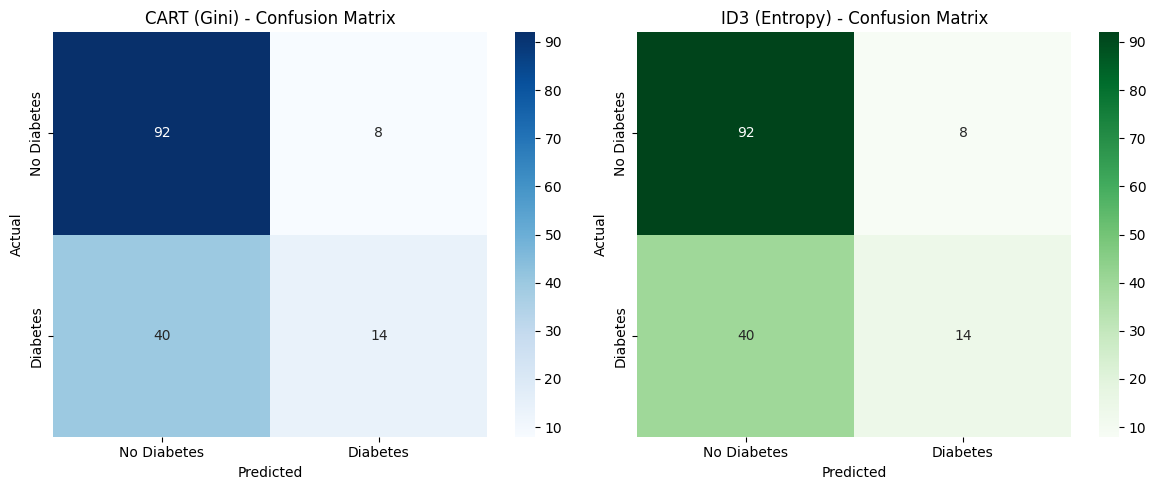

In [17]:
# ---- Confusion Matrix Heatmap (2x1 Comparison) ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cart_cm = confusion_matrix(y_test, cart_pred)
id3_cm = confusion_matrix(y_test, id3_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cart_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title('CART (Gini) - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(id3_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_title('ID3 (Entropy) - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**11:03 PM
Step 8: ROC Curve Plot (2x1 Comparison)**

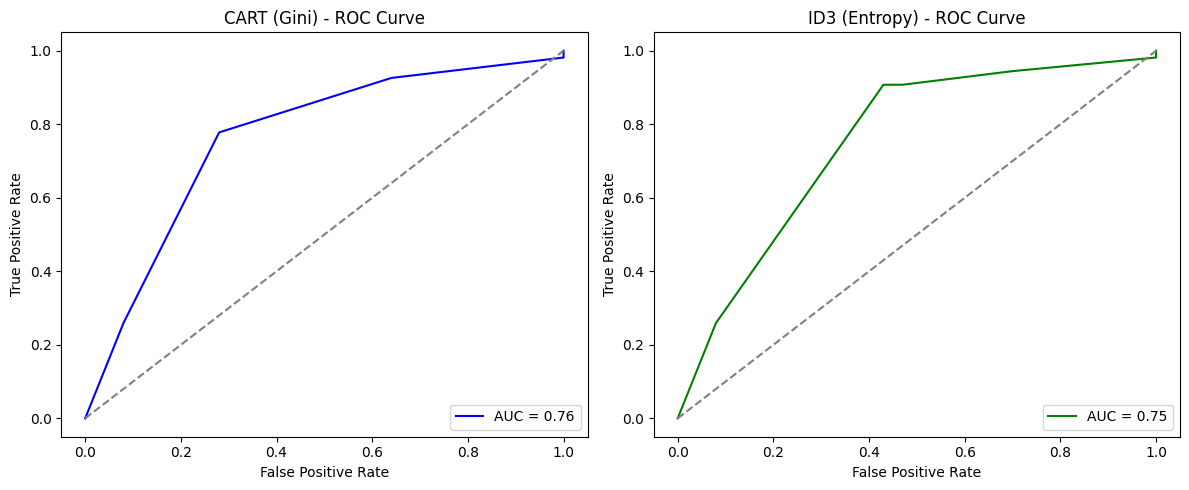

In [18]:
# ---- ROC Curve Plot (2x1 Comparison) ----
from sklearn.metrics import roc_curve, auc

cart_fpr, cart_tpr, _ = roc_curve(y_test, cart_proba)
id3_fpr, id3_tpr, _ = roc_curve(y_test, id3_proba)

cart_auc = auc(cart_fpr, cart_tpr)
id3_auc = auc(id3_fpr, id3_tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(cart_fpr, cart_tpr, color='blue', label=f'AUC = {cart_auc:.2f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('CART (Gini) - ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].plot(id3_fpr, id3_tpr, color='green', label=f'AUC = {id3_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ID3 (Entropy) - ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Step 9: Decision Boundary Plot (2x1 Comparison)**

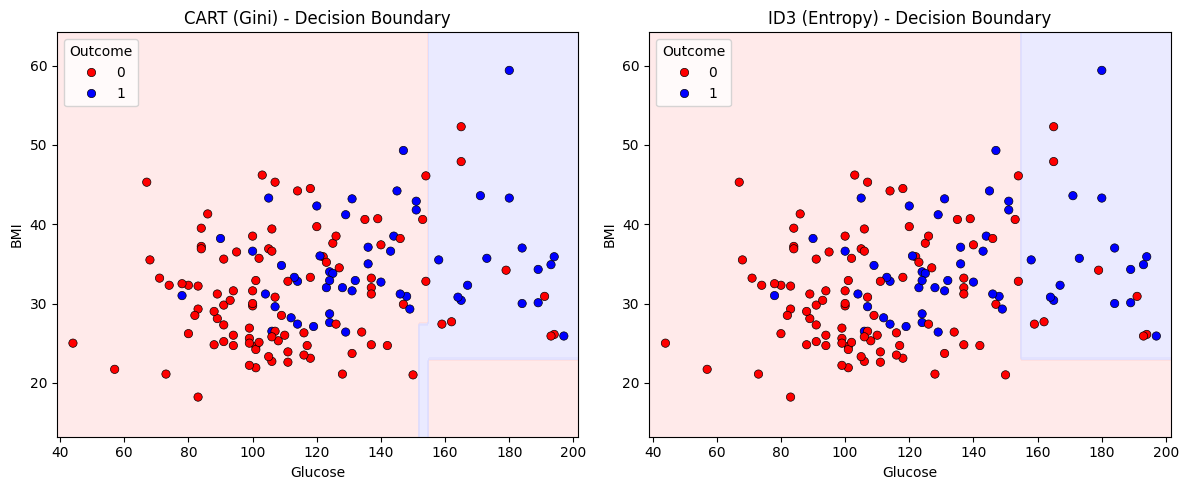

In [19]:
# ---- Decision Boundary Plot (2x1 Comparison) ----
from matplotlib.colors import ListedColormap

# Use 2 features for visualization
feat1, feat2 = 'Glucose', 'BMI'
X_2d_train = X_train[[feat1, feat2]].values
X_2d_test = X_test[[feat1, feat2]].values

# Retrain both models on 2D data using their best tuned params
cart_2d = DecisionTreeClassifier(criterion='gini',
                                   max_depth=cart_grid.best_params_['max_depth'],
                                   min_samples_split=cart_grid.best_params_['min_samples_split'],
                                   random_state=42)
cart_2d.fit(X_2d_train, y_train)

id3_2d = DecisionTreeClassifier(criterion='entropy',
                                  max_depth=id3_grid.best_params_['max_depth'],
                                  min_samples_split=id3_grid.best_params_['min_samples_split'],
                                  random_state=42)
id3_2d.fit(X_2d_train, y_train)

# Create mesh grid
x_min, x_max = X_2d_test[:, 0].min() - 5, X_2d_test[:, 0].max() + 5
y_min, y_max = X_2d_test[:, 1].min() - 5, X_2d_test[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

cmap_light = ListedColormap(['#FFDDDD', '#DDDDFF'])
cmap_bold = ['red', 'blue']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CART decision boundary
Z = cart_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
sns.scatterplot(x=X_2d_test[:, 0], y=X_2d_test[:, 1], hue=y_test,
                palette=cmap_bold, ax=axes[0], edgecolor='k')
axes[0].set_title('CART (Gini) - Decision Boundary')
axes[0].set_xlabel(feat1)
axes[0].set_ylabel(feat2)

# ID3 decision boundary
Z = id3_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
sns.scatterplot(x=X_2d_test[:, 0], y=X_2d_test[:, 1], hue=y_test,
                palette=cmap_bold, ax=axes[1], edgecolor='k')
axes[1].set_title('ID3 (Entropy) - Decision Boundary')
axes[1].set_xlabel(feat1)
axes[1].set_ylabel(feat2)

plt.tight_layout()
plt.show()

**11:04 PM
Step 10: Evaluation Metrics Bar Chart (Combined Comparison)**

In [ ]:
# ---- Evaluation Metrics Bar Chart (Combined Comparison) ----
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
cart_values = [cart_metrics[m] for m in metrics_names]
id3_values = [id3_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, cart_values, width, label='CART (Gini)', color='steelblue')
bars2 = ax.bar(x + width/2, id3_values, width, label='ID3 (Entropy)', color='seagreen')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('CART vs ID3 - Evaluation Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1)
ax.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Step 11: DT Structure Visualization (Optimized Tree)**

In [ ]:
# ---- DT Structure Visualization (Optimized CART Tree) ----
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(cart_best,
          feature_names=X.columns,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Optimized CART (Gini) - Decision Tree Structure')
plt.show()